# Luminosity Schechter

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.integrate import quad

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *
from mappers import DepthMapper

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## Luminosity sampling

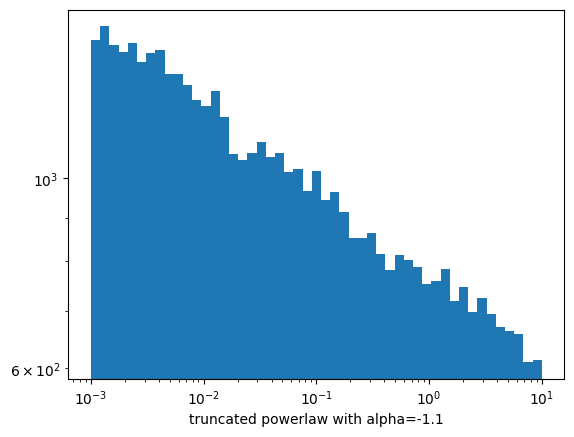

In [3]:
def sample_truncated_power_law(alpha, xmin, xmax, size=None):
    """
    Sample from a truncated power-law distribution p(x) ∝ x^alpha
    for xmin <= x <= xmax, with alpha < -1.

    Parameters:
        alpha (float): exponent (must be < -1)
        xmin (float): lower bound (> 0)
        xmax (float): upper bound (> xmin)
        size (int): number of samples

    Returns:
        numpy array of samples
    """
    if alpha == -1:
        raise ValueError("alpha = -1 requires a different (logarithmic) treatment")

    # Generate uniform random numbers
    u = np.random.uniform(0, 1, size)

    # Inverse CDF
    exponent = alpha + 1
    xmin_exp = xmin ** exponent
    xmax_exp = xmax ** exponent

    samples = (u * (xmax_exp - xmin_exp) + xmin_exp) ** (1 / exponent)

    return samples


x = sample_truncated_power_law(-1.1, 1e-3, 10, npix)
bins = np.logspace(np.log10(np.min(x)), np.log10(np.max(x)), 50)
get_hist(x, xlabel='truncated powerlaw with alpha=-1.1', bins=bins);
plt.yscale('log');
plt.xscale('log');

#### Schechter ratio:

Number of rejects = 14816


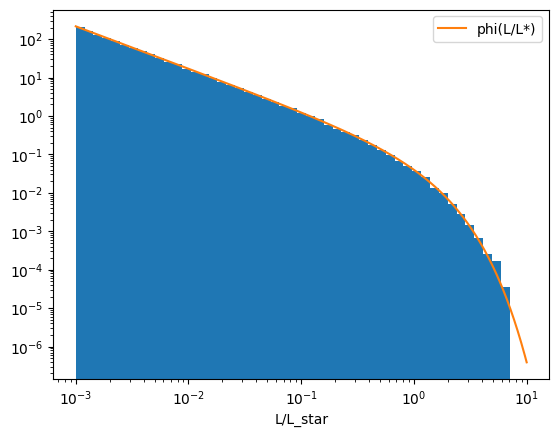

In [4]:
def proba_schechter_lumRatio(x, alpha, phi_star=1):
        return phi_star * np.power(x, alpha) * np.exp(-x)


def generate_schechter_lumRatio(N, alpha, x_min, x_max, phi_star=1, get_proba=False):
    """Generate N randomized luminosities, by using a reject test and Schechter's law."""
    samples = []
    reject = 0
    
    while len(samples) < N:
        L_cand = sample_truncated_power_law(alpha, x_min, x_max)
        
        # Acceptance ratio:
        # f(x) = x^alpha * exp(-x)
        # g(x) = x^alpha (on ignore la constante de normalisation qui s'annule)
        # f(x)/g(x) = exp(-x)
        acceptance_ratio = np.exp(-L_cand)
        
        # Acceptance test:
        u = np.random.uniform(0, 1)
        if u < acceptance_ratio:
            samples.append(L_cand)
        else:
            reject += 1
    print('Number of rejects =', reject)
    if get_proba: return np.array(samples), np.array(proba)
    else: return np.array(samples)


L_ratio = generate_schechter_lumRatio(npix, -1.1, 1e-3, 10)
bins = np.logspace(np.log10(np.min(L_ratio)), np.log10(np.max(L_ratio)), 50)
get_hist(L_ratio, xlabel='L/L_star', bins=bins, log=True, density=True)
plt.xscale('log');


L_test = np.logspace(-3, 1, 1000)
phi_test = proba_schechter_lumRatio(L_test, -1.1)
plt.plot(L_test, phi_test / np.trapz(phi_test, L_test), label = 'phi(L/L*)') #np.trapz ti normalize phi.
plt.legend();

### z, m, M, L, dL_mpc:

In [5]:
def generate_schechter_lum(N, L_star, alpha, L_min, L_max, phi_star):
    x_min, x_max = L_min/L_star, L_max/L_star
    return L_star*generate_schechter_lumRatio(N, alpha, x_min, x_max, phi_star)


def lum2absMag(L, M_sun=4.83, L_sun=1):
    return M_sun - 2.5*np.log10(L/L_sun)


def get_dL(zi, H0=67.4, Om=0.315, Ol=0.685, c=3e8):
    '''Compute the luminosity distance depending on the redshift z, the Hubble constant H0, the cosmological parameters Om and Ol, and the speed of ligt c.'''
    inv_Ez = lambda zp: 1.0 / np.sqrt(Om * (1 + zp)**3 + Ol)
    integral, _ = quad(inv_Ez, 0, zi)
    return (c / H0) * (1 + zi) * integral


def lum2flux(L, dL):
    return L/(4*np.pi * (dL**2))


def generate_lumMag(N, L_min=1e7, L_max=1e11,  L_star=1e10, alpha=-1.1, z_min=0.01, z_max=3.0, phi_star=1, to_table=True, **kwargs):
    #Cosmological Parameters  (Planck 2018):
    H0 = kwargs.get('H0', 67.4)
    Om = kwargs.get('Om', 0.315)
    Ol = kwargs.get('Ol', 0.685)
    c = kwargs.get('c', 3e5) #speed of ligt in km/s (because H0 is in Km/s/Mpc)
    M_sun = kwargs.get('M_sun', 4.83) #Absolute magnitude of Sun
    L_sun = kwargs.get('L_sun', 1) #Luminosity of Sun
    
    z = np.random.uniform(z_min, z_max, N) #Redshift
    dL_mpc = np.array([get_dL(zi, H0, Om, Ol, c) for zi in z]) #luminosity distance in Mpc
    L = generate_schechter_lum(N, L_star, alpha, L_min, L_max, phi_star) #luminosities
    M = lum2absMag(L, M_sun, L_sun) #Absolute magnitudes
    m = M + 5*np.log10(dL_mpc) + 25 #Aparent magnitudes

    if to_table:
        table = Table({"z":z, "dL":dL_mpc, "L":L, "M":M, "m":m})
        table["dL"].unit = u.Mpc
        table["L"].unit = u.Lsun
        return table
    else:
        return z, m, M, L, dL_mpc



data = generate_lumMag(npix, to_table=True)
data

Number of rejects = 14349


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
1.325577798937269,9631.517338142094,97143057.05907388,-15.138529416130472,29.77994413770235
2.3892128152289707,19793.61055358434,44458374.80426924,-14.289883957061365,32.192741148502236
2.0381613874757107,16318.85674864519,3430359816.222807,-19.008349190780585,27.055099459633883
0.53177381528905,3153.4253369153457,1622545928.1426942,-18.195492497204334,24.298420266489238
1.9951386638667925,15900.014413578361,10389251.603937617,-12.711460660041512,33.29552693003078
2.759000603270636,23549.53187380493,109561327.77773412,-15.269143217111273,31.590768175320726
0.8028240243660073,5198.281872027655,498869541.36408806,-16.914967471907907,26.664331653192956
1.9604727941481122,15563.740490776505,105625310.26965801,-15.229419994200937,30.73114990971017


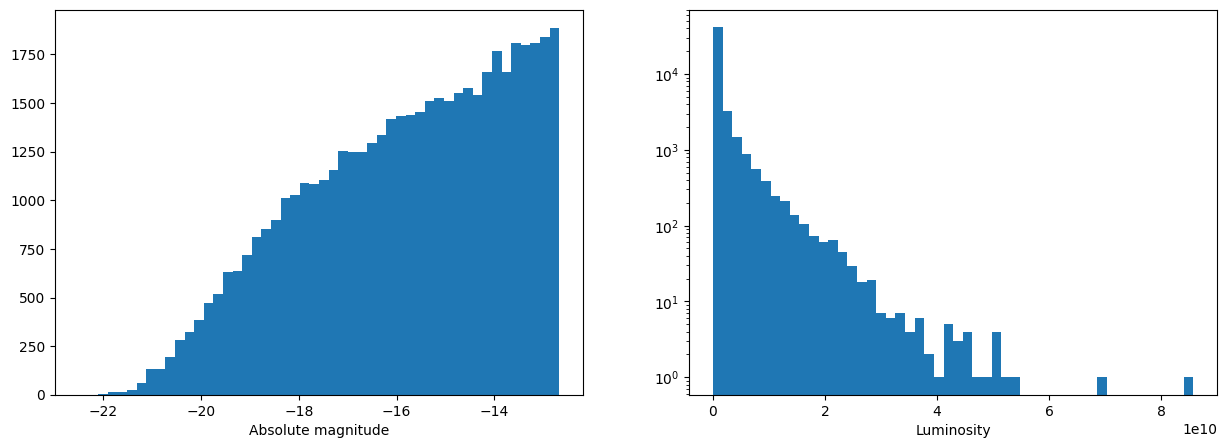

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=50, figax=(fig, ax[1]), log=True);

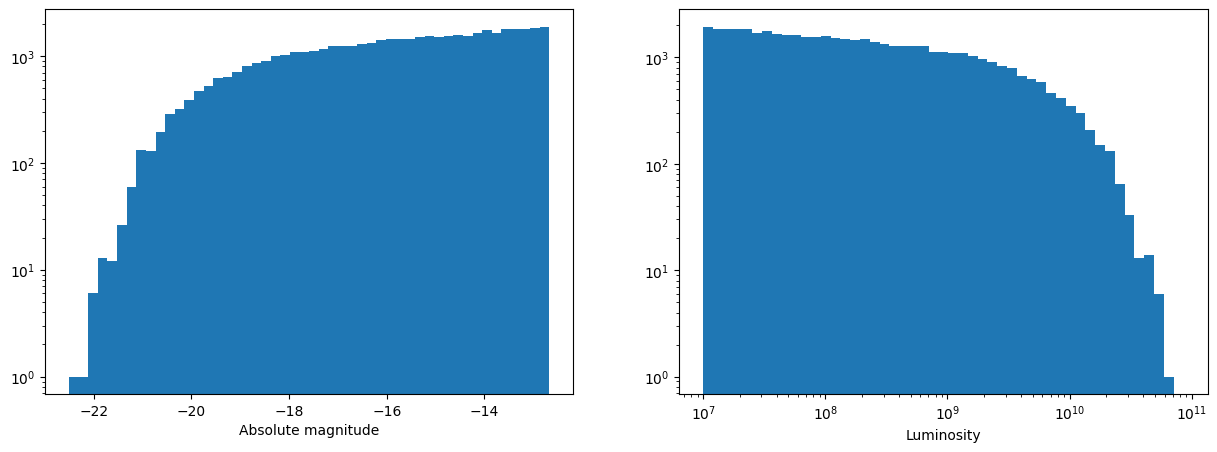

In [7]:
binsL = np.logspace(np.log10(np.min(data["L"])), np.log10(np.max(data["L"])), 50)
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
get_hist(data["M"], xlabel='Absolute magnitude', bins=50, figax=(fig, ax[0]))
get_hist(data["L"], xlabel='Luminosity', bins=binsL, figax=(fig, ax[1]))
ax[0].set_yscale('log')
ax[1].set_xscale('log')
ax[1].set_yscale('log');

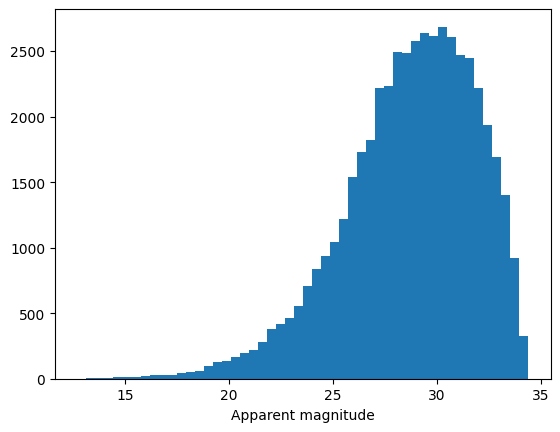

In [8]:
get_hist(data["m"], xlabel='Apparent magnitude', bins=50);

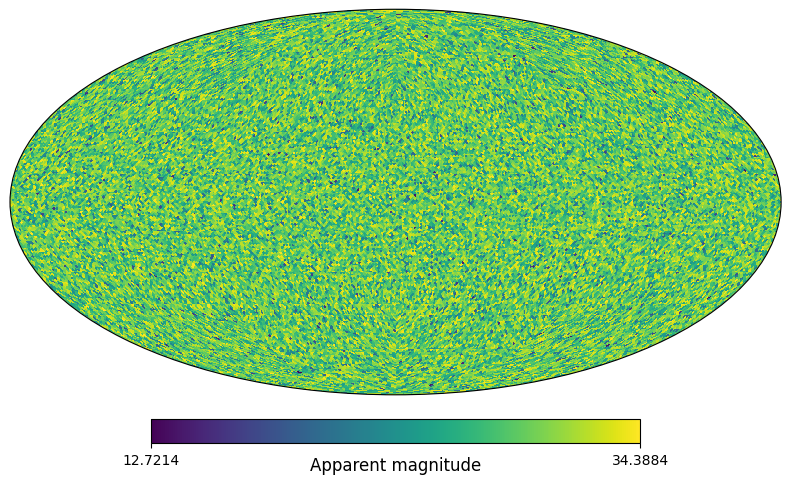

In [9]:
hp.projview(data["m"], unit="Apparent magnitude");

## $m_5$ magnitude

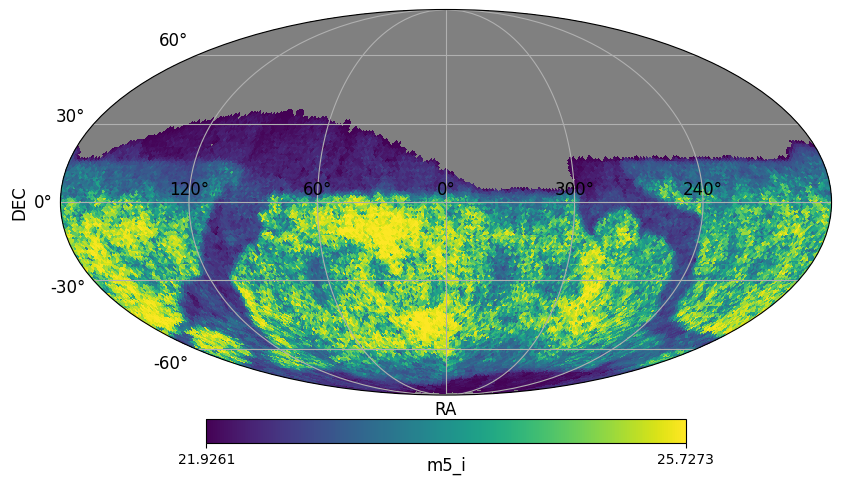

In [10]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
dm.select_band('i')
dm.set_mask()
dm.plot()

## N sources sampling

In [11]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True)
dataN

Number of rejects = 296032


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
1.6486000927242803,12591.468608019626,2549360212.441606,-18.686078008860683,26.814303926492816
1.1793362367490254,8340.263926368645,44599521.76285315,-14.293325504579263,30.31257346560698
1.1618866452070584,8188.529844925765,284014192.97816694,-16.30335010872748,28.262679572511306
0.6546299342574637,4052.973500292844,22257548.390042137,-13.538693315617524,29.50017550531866
1.7662620014620753,13701.028569282784,600882205.4306973,-17.116973357438305,28.566792502137837
1.581891595332759,11969.35389874031,10925067045.93986,-20.266060277170766,25.12429326275394
0.8441583681142434,5528.095523905771,12947421.306717813,-12.950458200236207,30.762419494339383
0.2949086304276196,1577.1469878931075,314212693.5284805,-16.413059314092976,24.576301540173848


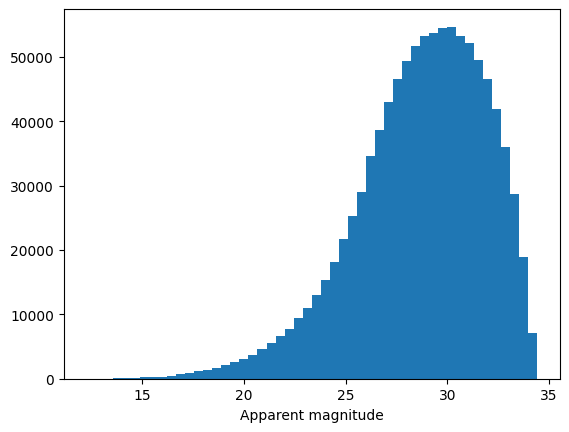

In [12]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50);

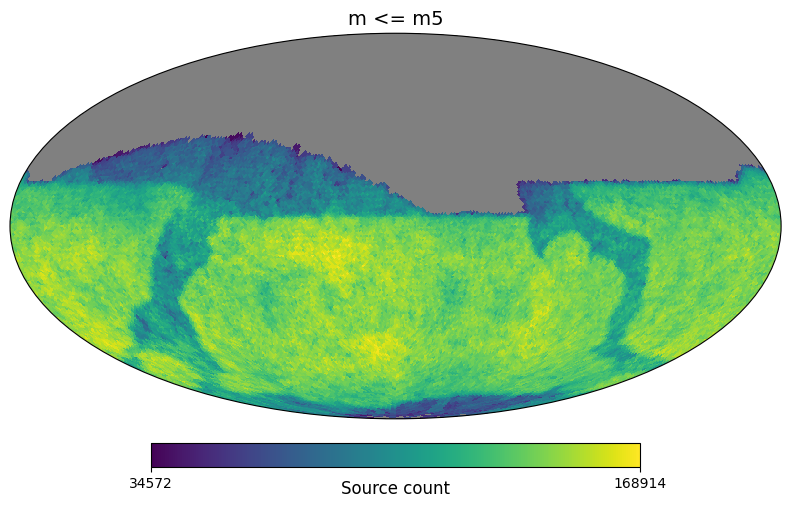

In [13]:
def get_cut_m52NSources_dask(m, m5, chunk_size=100_000):
    # 1. Conversion en dask arrays avec définition des morceaux (chunks)
    # On définit les chunks sur la dimension qui pose problème (m)
    m = da.from_array(np.array(m), chunks=chunk_size)
    m5 = da.from_array(np.array(m5), chunks=chunk_size)

    # 2. Reshape (Dask gère cela de manière "lazy", sans copier les données)
    if (m.ndim == 1) and (m5.ndim == 1):
        m = m.reshape(1, -1)
        m5 = m5.reshape(-1, 1)

    # 3. Opération de broadcast et masque
    # Dask ne va pas créer la matrice géante en RAM, il va travailler bloc par bloc
    mask = m <= m5

    # 4. Comptage
    # On utilise .sum(axis=1) car c'est très efficace en Dask
    result_dask = mask.sum(axis=1)

    # 5. Calcul effectif
    # Jusqu'ici, rien n'a été calculé. .compute() lance l'exécution par morceaux.
    return result_dask.compute()

NSource_px = get_cut_m52NSources_dask(dataN["m"], dm.m5i.copy(), chunk_size=1e4)
NSource_px = hp.ma(NSource_px, badval=0)
hp.projview(NSource_px, nest=True, unit="Source count", title= "m <= m5");

In [14]:
def get_cut_m52nSources(m, m5):
    m, m5 = np.array(m), np.array(m5)
    if (m.ndim == 1) & (m5.ndim ==1):  m, m5 = m.reshape(1, -1), m5.reshape(-1, 1) #to broadcast m and m5
    mask = m <= m5
    return np.count_nonzero(mask, axis=1)

NSource_px = get_cut_m52nSources(dataN["m"], dm.m5i.copy())
hp.projview(NSource_px, nest=True);

MemoryError: Unable to allocate 45.8 GiB for an array with shape (49152, 1000000) and data type bool